<a href="https://colab.research.google.com/github/ztechbr/dissertacao_base_estatistica/blob/main/Zaroni_Dissertacao_Validacao_Estatistica_COLAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Validação estatística da dissertação Zaroni - Python 3 / Google Colab

Notebook completo para validação, análise psicométrica, **Principal Component Analysis (PCA)**, análise fatorial e **PLS-SEM/PLS Path Modeling** usando o XLS sintético de 2.000 respondentes.

A base e o modelo seguem a dissertação **Antecedentes e resultados do uso efetivo da plataforma tecnológica LMS na educação a distância: uma extensão ao modelo TAM**, IBMEC, 2014.

## O que o notebook executa

1. leitura e validação do XLS;
2. recodificação dos itens reversos;
3. estatística descritiva e normalidade;
4. outliers multivariados por Mahalanobis, `alpha=0,001`;
5. Alfa de Cronbach, correlação item-total e alfa se item removido;
6. KMO e Bartlett;
7. PCA global e por construto;
8. análise paralela de Horn;
9. EFA com Varimax;
10. fator único de Harman;
11. modelo de mensuração PLS;
12. depuração por carga externa e cross-loading;
13. AVE e Composite Reliability;
14. Fornell-Larcker e HTMT;
15. modelo estrutural PLS;
16. R2, f2, VIF e Q2;
17. efeitos diretos, indiretos e totais;
18. moderação `COMP x UP -> IUE`;
19. bootstrap dos caminhos;
20. comparação com os resultados reportados em 2014;
21. exportação de todas as tabelas para CSV/XLSX/ZIP.

> **Escopo:** a base incluída no ZIP é sintética. Ela serve para testar e auditar os métodos. Não é evidência empírica sobre alunos.

## 0. O método original e as ampliações deste notebook

### Reproduzido da dissertação

- PLS para o modelo estrutural;
- construtos reflexivos e desempenho observado/formativo;
- `AC` separado em `ACFoco` e `ACPlay`;
- Mahalanobis com `alpha = 0,001`;
- bootstrap com **1.000 amostras**;
- carga externa de referência `>= 0,70`;
- `AVE > 0,50`;
- `CR > 0,70`;
- `Alfa > 0,70`;
- validade discriminante por Fornell-Larcker.

### Diagnósticos complementares atuais

- análise paralela de Horn;
- HTMT;
- VIF do modelo estrutural;
- f2;
- Q2 preditivo por cross-validation.

O PLS abaixo é uma implementação Python didática e auditável. Ele não é uma clonagem interna do SmartPLS 2.0.M3, portanto diferenças numéricas são esperadas.

In [1]:
# Execute uma vez em uma sessão nova do Colab.
%pip -q install pandas numpy scipy scikit-learn statsmodels matplotlib openpyxl joblib tqdm factor_analyzer networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
from pathlib import Path
from collections import defaultdict, deque
from dataclasses import dataclass
import json, math, warnings, zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_predict
from statsmodels.stats.outliers_influence import variance_inflation_factor
from factor_analyzer import FactorAnalyzer
from joblib import Parallel, delayed
from tqdm.auto import tqdm
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 150)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# -------------------------
# CONFIGURAÇÃO DO ESTUDO
# -------------------------
FAST_MODE = False
BOOTSTRAP_SAMPLES = 1000 if not FAST_MODE else 100
PARALLEL_ITERATIONS = 300 if not FAST_MODE else 50
MAHALANOBIS_ALPHA = 0.001
LOADING_THRESHOLD = 0.70
AVE_THRESHOLD = 0.50
CR_THRESHOLD = 0.70
ALPHA_THRESHOLD = 0.70
RANDOM_SEED = 2014
N_JOBS = -1
KEEP_OUTLIERS = False

OUTPUT_DIR = Path('/content/zaroni_resultados')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('FAST_MODE:', FAST_MODE)
print('Bootstrap:', BOOTSTRAP_SAMPLES)
print('Parallel analysis:', PARALLEL_ITERATIONS)

FAST_MODE: False
Bootstrap: 1000
Parallel analysis: 300


# 1. Leitura do XLS

O notebook procura o arquivo `Dissertacao_Zaroni_Sintetico_2000.xlsx` em `/content`, em `/content/data` ou ao lado do notebook. Se não encontrar, solicita upload.

A configuração analítica é lida do próprio workbook, principalmente das abas:

- `Dados_Sinteticos`;
- `Dicionario_Itens`;
- `Hipoteses_Modelo`;
- `Parametros_2014`;
- `Escala_Likert`.

Assim, o XLS é a fonte operacional do questionário e do modelo.

In [3]:
candidates = [
    Path('/content/data/Dissertacao_Zaroni_Sintetico_2000.xlsx'),
    Path('/content/Dissertacao_Zaroni_Sintetico_2000.xlsx'),
    Path('data/Dissertacao_Zaroni_Sintetico_2000.xlsx'),
    Path('Dissertacao_Zaroni_Sintetico_2000.xlsx'),
]

xlsx_path = next((p for p in candidates if p.exists()), None)
if xlsx_path is None:
    found = list(Path('/content').rglob('Dissertacao_Zaroni_Sintetico_2000*.xlsx'))
    if found:
        xlsx_path = found[0]

if xlsx_path is None:
    from google.colab import files
    print('Faça upload do XLSX fornecido no ZIP.')
    uploaded = files.upload()
    names = [n for n in uploaded if n.lower().endswith('.xlsx')]
    if not names:
        raise FileNotFoundError('Nenhum XLSX enviado.')
    xlsx_path = Path('/content') / names[0]

print('XLSX:', xlsx_path)

xls = pd.ExcelFile(xlsx_path)
required = {'Dados_Sinteticos','Dicionario_Itens','Hipoteses_Modelo','Parametros_2014','Escala_Likert'}
missing = required.difference(xls.sheet_names)
if missing:
    raise ValueError(f'Abas obrigatórias ausentes: {sorted(missing)}')

df_raw = pd.read_excel(xlsx_path, sheet_name='Dados_Sinteticos')
dictionary = pd.read_excel(xlsx_path, sheet_name='Dicionario_Itens')
hypotheses_2014 = pd.read_excel(xlsx_path, sheet_name='Hipoteses_Modelo')
benchmarks_2014 = pd.read_excel(xlsx_path, sheet_name='Parametros_2014')
likert_scale = pd.read_excel(xlsx_path, sheet_name='Escala_Likert')

print('Base:', df_raw.shape)
print('Abas:', xls.sheet_names)
display(df_raw.head())
display(dictionary.head(10))

XLSX: /content/Dissertacao_Zaroni_Sintetico_2000.xlsx
Base: (2000, 98)
Abas: ['README', 'Dados_Sinteticos', 'Dicionario_Itens', 'Hipoteses_Modelo', 'Parametros_2014', 'Escala_Likert']


,respondent_id,genero,idade,escolaridade,nivel_curso,ies,curso,tipo_curso,local_acesso,dispositivo,lms,ead_anterior,uso_semanal,DES,ATEAD1,ATEAD2,ATEAD3,ATEAD4,ATEAD5,ATEAD6,ATEAD7,ATEAD8,SAT1,SAT2,SAT3,IUE1,IUE2,IUE3,IUE4,AT1,AT2,AT3,AT4,UP1,UP2,UP3,UP4,UP5,UP6,FUP1,FUP2,FUP3,FUP4,FUP5,FUP6,COMP1,COMP2,COMP3,COMP4,COMP5,COMP6,ORG1,ORG2,ORG3,ORG4,FSI1,FSI2,FSI3,FSI4,FSI5,FSI6,ISI1,ISI2,ISI3,QI1,QI2,QI3,QI4,QI5,AC1,AC2,AC3,AC4,AC5,AC6,INS1,INS2,INS3,INS4,INS5,INS6,INS7,INS8,INS9,FLEX1,FLEX2,FLEX3,FLEX4,FLEX5,FLEX6,FLEX7,FLEX8,IES1,IES2,IES3,IES4,IES5,synthetic_outlier_injected
0,1,FEMININO,39,ENS.SUPERIOR,POS-GRADUACAO,IES_RJ_PRIV_1,ADM/GEST.,TOTAL_EAD,CASA,COMPUTADOR,BLACKBOARD,9,8,5.2800,4,4,4,4,4,4,4,6,5,4,5,6,5,4,5,3,3,3,4,3,5,5,4,4,4,6,6,5,4,6,6,6,4,6,6,3,6,6,6,6,6,3,2,5,5,4,4,7,6,7,5,5,6,6,4,6,5,4,4,5,4,5,5,4,5,5,5,4,4,5,6,3,5,5,6,6,6,7,3,3,3,2,1,False
1,2,MASCULINO,43,ENS.SUPERIOR,GRADUACAO/TECNOLOGO,IES_RJ_PRIV_1,ADM/GEST.,TOTAL_EAD,CASA,TABLET,BLACKBOARD,10,11,9.2700,7,7,7,7,7,7,7,7,7,7,2,6,7,6,7,7,7,6,7,6,7,7,6,6,5,7,7,7,7,7,7,3,5,6,4,4,6,7,7,7,7,5,6,6,7,6,6,7,7,7,2,2,2,3,2,7,7,7,7,1,7,7,7,7,7,7,7,7,7,7,7,7,7,6,7,7,6,7,7,7,7,7,7,False
2,3,FEMININO,25,ENS.SUPERIOR,GRADUACAO/TECNOLOGO,IES_RJ_PRIV_2,MARKETING,BLENDED,CASA,COMPUTADOR,BLACKBOARD,0,17,6.6600,6,5,7,5,6,6,7,6,5,7,1,4,5,5,6,5,5,6,5,5,5,3,5,6,7,5,7,6,7,5,4,4,3,5,4,3,4,5,6,4,6,6,7,5,5,5,6,4,5,4,6,6,6,6,4,5,5,3,4,2,3,6,7,5,7,6,6,7,6,6,3,4,4,6,4,4,4,4,6,6,5,6,1,False
3,4,MASCULINO,27,ENS.MEDIO,GRADUACAO/TECNOLOGO,IES_RJ_PRIV_1,ADM/GEST.,BLENDED,CASA,TABLET,MOODLE,7,2,6.5800,2,4,5,3,3,4,3,3,5,4,3,7,6,7,7,6,7,6,7,6,6,7,7,6,7,5,6,6,6,5,5,6,6,5,5,4,5,6,7,6,6,6,6,6,4,4,5,5,6,5,6,7,6,5,4,7,7,7,7,1,7,6,5,6,5,4,7,6,5,5,4,5,4,5,5,2,4,4,7,6,6,7,3,False
4,5,MASCULINO,38,ENS.SUPERIOR,GRADUACAO/TECNOLOGO,IES_RJ_PRIV_1,ADM/GEST.,TOTAL_EAD,CASA,COMPUTADOR,MOODLE,8,20,7.4200,5,5,5,4,5,7,4,6,5,6,1,7,6,7,7,6,7,7,7,7,7,7,7,7,7,6,7,7,7,7,6,7,6,7,7,1,7,3,4,2,3,7,7,7,7,7,7,7,7,7,7,7,7,7,7,5,5,5,7,1,7,6,6,7,5,7,7,7,7,7,7,7,7,7,6,7,7,7,7,7,7,6,7,False


,Código,Número original,Construto original,Dimensão PLS,Reverso,Item exato do Apêndice A,Fonte
0,ATEAD1,1.1000,ATEAD,ATEAD,NÃO,Estudar a distância é uma boa ideia.,"Aberasturi; Kongrith, 2006"
1,ATEAD2,1.2000,ATEAD,ATEAD,NÃO,Os cursos EaD são importantes para uma carreir...,"Aberasturi; Kongrith, 2006"
2,ATEAD3,1.3000,ATEAD,ATEAD,NÃO,O curso EaD é bem aceito pelo mercado.,"Aberasturi; Kongrith, 2006"
3,ATEAD4,1.4000,ATEAD,ATEAD,NÃO,Um curso EaD possui a mesma qualidade que um c...,"Aberasturi; Kongrith, 2006"
4,ATEAD5,1.5000,ATEAD,ATEAD,NÃO,Gosto de estudar a distância.,"Aberasturi; Kongrith, 2006"
5,ATEAD6,1.6000,ATEAD,ATEAD,NÃO,O curso EaD pode substituir o curso tradicional.,"Aberasturi; Kongrith, 2006"
6,ATEAD7,1.7000,ATEAD,ATEAD,NÃO,Vale a pena investir numa formação a distância.,"Aberasturi; Kongrith, 2006"
7,ATEAD8,1.8000,ATEAD,ATEAD,NÃO,Eu recomendaria a EaD aos meus amigos.,"Aberasturi; Kongrith, 2006"
8,SAT1,2.1000,SAT,SAT,NÃO,"No geral, fiquei satisfeito com a minha experi...","Artino, 2007"
9,SAT2,2.2000,SAT,SAT,NÃO,Este curso online atendeu minha necessidade de...,"Artino, 2007"


# 2. Especificação automática da escala

Os itens e seus construtos são obtidos da aba `Dicionario_Itens`.

## Recodificação reversa

Para uma escala de 1 a 7:

\[
x_{rev}=8-x
\]

Os itens reversos devem ser recodificados antes de confiabilidade, PCA, fatores e PLS.

In [4]:
# Localiza colunas mesmo que o cabeçalho tenha acentos.
colmap = {}
for c in dictionary.columns:
    low = str(c).strip().lower()
    if low.startswith('cód') or low.startswith('cod'):
        colmap['code'] = c
    elif 'dimens' in low:
        colmap['dimension'] = c
    elif 'revers' in low:
        colmap['reverse'] = c
    elif 'construto original' in low:
        colmap['construct_original'] = c
    elif 'item' in low:
        colmap['item_text'] = c
    elif 'fonte' in low:
        colmap['source'] = c

for k in ['code','dimension','reverse']:
    if k not in colmap:
        raise ValueError(f'Coluna {k} não localizada no dicionário: {colmap}')

ITEM_CODES = dictionary[colmap['code']].astype(str).tolist()
REVERSE_ITEMS = dictionary.loc[
    dictionary[colmap['reverse']].astype(str).str.upper().isin(['SIM','YES','TRUE','1']),
    colmap['code']
].astype(str).tolist()

MEASUREMENT_BLOCKS = (
    dictionary.groupby(colmap['dimension'])[colmap['code']]
    .apply(lambda s: [str(v) for v in s])
    .to_dict()
)
MEASUREMENT_BLOCKS['DES'] = ['DES']

missing_items = [c for c in ITEM_CODES + ['DES'] if c not in df_raw.columns]
if missing_items:
    raise ValueError(f'Variáveis ausentes no XLS: {missing_items}')

print('Itens:', len(ITEM_CODES))
print('Reversos:', REVERSE_ITEMS)
for c, items in MEASUREMENT_BLOCKS.items():
    print(f'{c:8s}: {len(items)}')

Itens: 83
Reversos: ['SAT3', 'COMP5', 'AC5']
ACFoco  : 3
ACPlay  : 3
AT      : 4
ATEAD   : 8
COMP    : 6
FLEX    : 8
FSI     : 6
FUP     : 6
IES     : 5
INS     : 9
ISI     : 3
IUE     : 4
ORG     : 4
QI      : 5
SAT     : 3
UP      : 6
DES     : 1


# 3. Funções de pré-processamento

## Mahalanobis

A distância multivariada é:

\[
D_i^2=(x_i-\mu)^T\Sigma^{-1}(x_i-\mu)
\]

A dissertação adotou `alpha = 0,001`. Este código usa pseudo-inversa para lidar com alta correlação entre indicadores.

In [5]:
# ============================================================
# FUNÇÕES: PREPROCESSAMENTO
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import chi2


def reverse_score(df: pd.DataFrame, items: list[str], min_value: int = 1, max_value: int = 7) -> pd.DataFrame:
    out = df.copy()
    for col in items:
        if col in out.columns:
            out[col] = min_value + max_value - pd.to_numeric(out[col], errors="coerce")
    return out


def validate_likert(df: pd.DataFrame, columns: list[str], min_value: int = 1, max_value: int = 7) -> pd.DataFrame:
    rows = []
    for col in columns:
        if col not in df:
            rows.append((col, 0, 0, 0, "AUSENTE"))
            continue
        s = pd.to_numeric(df[col], errors="coerce")
        invalid = int(((s < min_value) | (s > max_value)).sum())
        rows.append((col, int(s.notna().sum()), int(s.isna().sum()), invalid, "OK" if invalid == 0 else "INVALIDO"))
    return pd.DataFrame(rows, columns=["item", "n_validos", "n_ausentes", "fora_1_7", "status"])


def mahalanobis_outliers(df_numeric: pd.DataFrame, alpha: float = 0.001) -> tuple[pd.DataFrame, pd.Series]:
    """Mahalanobis com pseudo-inversa. Retorna tabela e mascara de outliers.

    A dissertacao usou alpha=0.001. Em dados Likert altamente correlacionados,
    a pseudo-inversa evita falhas por singularidade.
    """
    X = df_numeric.apply(pd.to_numeric, errors="coerce")
    X = X.fillna(X.median(numeric_only=True))
    arr = X.to_numpy(float)
    mu = arr.mean(axis=0)
    centered = arr - mu
    cov = np.cov(centered, rowvar=False)
    inv_cov = np.linalg.pinv(cov)
    d2 = np.einsum("ij,jk,ik->i", centered, inv_cov, centered)
    dfree = max(1, np.linalg.matrix_rank(cov))
    cutoff = chi2.ppf(1 - alpha, df=dfree)
    mask = pd.Series(d2 > cutoff, index=X.index, name="outlier_mahalanobis")
    result = pd.DataFrame({"mahalanobis_d2": d2, "cutoff": cutoff, "df": dfree, "outlier": mask.values}, index=X.index)
    return result, mask


def zscore_frame(df: pd.DataFrame) -> pd.DataFrame:
    x = df.apply(pd.to_numeric, errors="coerce")
    return (x - x.mean()) / x.std(ddof=0).replace(0, 1)

# 4. Estatística descritiva e normalidade

A escala Likert é ordinal. Média e desvio-padrão são usados aqui como resumos operacionais, acompanhados por mediana, quartis, assimetria e curtose.

O teste D'Agostino K2 é apenas diagnóstico. Em amostras grandes, pequenos desvios tendem a resultar em `p` muito pequeno.

In [6]:
# ============================================================
# FUNÇÕES: DESCRITIVOS
# ============================================================

import numpy as np
import pandas as pd
from scipy import stats


def numeric_descriptives(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for c in df.select_dtypes(include=[np.number]).columns:
        s = df[c].dropna().astype(float)
        if len(s) == 0:
            continue
        rows.append({
            "variavel": c, "n": len(s), "media": s.mean(), "dp": s.std(ddof=1),
            "mediana": s.median(), "min": s.min(), "max": s.max(),
            "assimetria": stats.skew(s, bias=False), "curtose_excesso": stats.kurtosis(s, fisher=True, bias=False),
            "q25": s.quantile(.25), "q75": s.quantile(.75),
        })
    return pd.DataFrame(rows).set_index("variavel")


def categorical_frequencies(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    frames = []
    for c in columns:
        if c not in df:
            continue
        vc = df[c].value_counts(dropna=False)
        sub = pd.DataFrame({"variavel": c, "categoria": vc.index.astype(str), "n": vc.values})
        sub["percentual"] = 100 * sub["n"] / len(df)
        frames.append(sub)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=["variavel", "categoria", "n", "percentual"])


def item_normality(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    rows = []
    for c in columns:
        if c not in df:
            continue
        s = pd.to_numeric(df[c], errors="coerce").dropna().astype(float)
        if len(s) < 8:
            continue
        k2, p = stats.normaltest(s)
        rows.append({"item": c, "n": len(s), "skew": stats.skew(s, bias=False), "kurtosis": stats.kurtosis(s, fisher=True, bias=False), "dagostino_k2": k2, "p": p})
    return pd.DataFrame(rows).set_index("item")

# 5. Psicometria

## Alfa de Cronbach

\[
lpha=rac{k}{k-1}\left(1-rac{\sum\sigma_i^2}{\sigma_T^2}
ight)
\]

## KMO e Bartlett

KMO avalia se as correlações parciais são suficientemente pequenas para justificar uma solução fatorial. Bartlett testa a hipótese de que a matriz de correlações é identidade.

## AVE

\[
AVE=rac{\sum\lambda_i^2}{k}
\]

## Composite Reliability

\[
CR=rac{(\sum\lambda_i)^2}{(\sum\lambda_i)^2+\sum(1-\lambda_i^2)}
\]

A dissertação usou `AVE > 0,50`, `CR > 0,70`, `Alfa > 0,70`.

In [7]:
# ============================================================
# FUNÇÕES: PSICOMETRIA
# ============================================================

import numpy as np
import pandas as pd
from scipy import stats


def cronbach_alpha(df: pd.DataFrame) -> float:
    x = df.apply(pd.to_numeric, errors="coerce").dropna(axis=0, how="any")
    k = x.shape[1]
    if k < 2 or x.shape[0] < 3:
        return float("nan")
    variances = x.var(axis=0, ddof=1).sum()
    total_var = x.sum(axis=1).var(ddof=1)
    return float(k / (k - 1) * (1 - variances / total_var)) if total_var > 0 else float("nan")


def corrected_item_total(df: pd.DataFrame) -> pd.Series:
    x = df.apply(pd.to_numeric, errors="coerce")
    out = {}
    for c in x.columns:
        others = x.drop(columns=c).sum(axis=1)
        out[c] = x[c].corr(others)
    return pd.Series(out, name="correlacao_item_total_corrigida")


def alpha_if_deleted(df: pd.DataFrame) -> pd.Series:
    return pd.Series({c: cronbach_alpha(df.drop(columns=c)) for c in df.columns}, name="alpha_se_item_removido")


def kmo(df: pd.DataFrame) -> tuple[float, pd.Series]:
    """Kaiser-Meyer-Olkin global e por item."""
    x = df.apply(pd.to_numeric, errors="coerce").dropna().to_numpy(float)
    r = np.corrcoef(x, rowvar=False)
    inv_r = np.linalg.pinv(r)
    denom = np.sqrt(np.outer(np.diag(inv_r), np.diag(inv_r)))
    partial = -inv_r / denom
    np.fill_diagonal(partial, 0)
    r2 = r ** 2
    p2 = partial ** 2
    np.fill_diagonal(r2, 0)
    kmo_item = r2.sum(axis=0) / (r2.sum(axis=0) + p2.sum(axis=0))
    kmo_total = r2.sum() / (r2.sum() + p2.sum())
    return float(kmo_total), pd.Series(kmo_item, index=df.columns, name="KMO")


def bartlett_sphericity(df: pd.DataFrame) -> dict:
    x = df.apply(pd.to_numeric, errors="coerce").dropna().to_numpy(float)
    n, p = x.shape
    r = np.corrcoef(x, rowvar=False)
    det = max(np.linalg.det(r), np.finfo(float).tiny)
    chi_square = -(n - 1 - (2 * p + 5) / 6) * np.log(det)
    dof = p * (p - 1) / 2
    p_value = stats.chi2.sf(chi_square, dof)
    return {"chi2": float(chi_square), "df": int(dof), "p": float(p_value)}


def composite_reliability(loadings: pd.Series) -> float:
    l = loadings.dropna().abs().to_numpy(float)
    if len(l) < 2:
        return float("nan")
    return float((l.sum() ** 2) / ((l.sum() ** 2) + np.sum(1 - l ** 2)))


def ave(loadings: pd.Series) -> float:
    l = loadings.dropna().to_numpy(float)
    return float(np.mean(l ** 2)) if len(l) else float("nan")


def fornell_larcker(scores: pd.DataFrame, ave_by_construct: pd.Series) -> pd.DataFrame:
    corr = scores.corr()
    out = corr.copy()
    for c in out.index:
        if c in ave_by_construct.index:
            out.loc[c, c] = np.sqrt(max(float(ave_by_construct[c]), 0))
    return out


def htmt(df: pd.DataFrame, blocks: dict[str, list[str]]) -> pd.DataFrame:
    constructs = [c for c in blocks if len(blocks[c]) >= 2 and all(i in df.columns for i in blocks[c])]
    result = pd.DataFrame(np.eye(len(constructs)), index=constructs, columns=constructs, dtype=float)
    corr = df[[i for c in constructs for i in blocks[c]]].corr().abs()
    for a_i, a in enumerate(constructs):
        for b_i in range(a_i + 1, len(constructs)):
            b = constructs[b_i]
            hetero = corr.loc[blocks[a], blocks[b]].to_numpy().ravel()
            mono_a = corr.loc[blocks[a], blocks[a]].to_numpy()
            mono_b = corr.loc[blocks[b], blocks[b]].to_numpy()
            ma = mono_a[np.triu_indices_from(mono_a, 1)]
            mb = mono_b[np.triu_indices_from(mono_b, 1)]
            denom = np.sqrt(np.nanmean(ma) * np.nanmean(mb))
            val = np.nanmean(hetero) / denom if denom > 0 else np.nan
            result.loc[a, b] = result.loc[b, a] = val
    return result


def harman_single_factor(df: pd.DataFrame) -> dict:
    x = df.apply(pd.to_numeric, errors="coerce").dropna()
    z = (x - x.mean()) / x.std(ddof=0).replace(0, 1)
    corr = np.corrcoef(z.to_numpy(), rowvar=False)
    eig = np.linalg.eigvalsh(corr)[::-1]
    explained_first = eig[0] / eig.sum()
    return {"first_eigenvalue": float(eig[0]), "first_factor_variance_pct": float(100 * explained_first)}

# 6. Principal Component Analysis e EFA

PCA é redução de dimensionalidade e utiliza variância total. Análise fatorial modela variância comum.

A análise paralela de Horn é incluída como diagnóstico adicional: retém componentes cujo autovalor observado excede o percentil 95 dos autovalores de dados aleatórios de mesma dimensão.

In [8]:
# ============================================================
# FUNÇÕES: PCA, ANÁLISE PARALELA E EFA
# ============================================================

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.preprocessing import StandardScaler


def run_pca(df: pd.DataFrame, n_components: int | None = None) -> dict:
    x = df.apply(pd.to_numeric, errors="coerce").dropna()
    z = StandardScaler().fit_transform(x)
    pca = PCA(n_components=n_components).fit(z)
    scores = pca.transform(z)
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    cols = [f"PC{i+1}" for i in range(pca.n_components_)]
    return {
        "model": pca,
        "scores": pd.DataFrame(scores, index=x.index, columns=cols),
        "loadings": pd.DataFrame(loadings, index=x.columns, columns=cols),
        "explained": pd.DataFrame({
            "eigenvalue": pca.explained_variance_,
            "variance_ratio": pca.explained_variance_ratio_,
            "cumulative": np.cumsum(pca.explained_variance_ratio_),
        }, index=cols),
    }


def parallel_analysis(df: pd.DataFrame, iterations: int = 200, percentile: float = 95, seed: int = 2014) -> pd.DataFrame:
    x = df.apply(pd.to_numeric, errors="coerce").dropna()
    z = StandardScaler().fit_transform(x)
    obs = np.linalg.eigvalsh(np.corrcoef(z, rowvar=False))[::-1]
    rng = np.random.default_rng(seed)
    rand = np.empty((iterations, z.shape[1]))
    for i in range(iterations):
        rx = rng.normal(size=z.shape)
        rand[i] = np.linalg.eigvalsh(np.corrcoef(rx, rowvar=False))[::-1]
    threshold = np.percentile(rand, percentile, axis=0)
    return pd.DataFrame({
        "component": np.arange(1, len(obs) + 1),
        "observed_eigenvalue": obs,
        f"random_p{int(percentile)}": threshold,
        "retain": obs > threshold,
    })


def varimax(Phi: np.ndarray, gamma: float = 1.0, q: int = 100, tol: float = 1e-6) -> np.ndarray:
    p, k = Phi.shape
    R = np.eye(k)
    d = 0.0
    for _ in range(q):
        d_old = d
        Lambda = Phi @ R
        u, s, vh = np.linalg.svd(Phi.T @ (Lambda ** 3 - (gamma / p) * Lambda @ np.diag(np.diag(Lambda.T @ Lambda))))
        R = u @ vh
        d = s.sum()
        if d_old and d / d_old < 1 + tol:
            break
    return Phi @ R


def exploratory_factor_analysis(df: pd.DataFrame, n_factors: int, rotation: str = "varimax", seed: int = 2014) -> pd.DataFrame:
    x = df.apply(pd.to_numeric, errors="coerce").dropna()
    z = StandardScaler().fit_transform(x)
    fa = FactorAnalysis(n_components=n_factors, random_state=seed).fit(z)
    load = fa.components_.T
    if rotation == "varimax":
        load = varimax(load)
    return pd.DataFrame(load, index=x.columns, columns=[f"F{i+1}" for i in range(n_factors)])

# 7. Implementação do PLS Path Modeling

A rotina abaixo executa Mode A para blocos reflexivos, estima escores latentes iterativamente e usa regressões sobre escores padronizados no modelo interno.

Também calcula:

- outer weights;
- outer loadings;
- AVE;
- CR;
- Alfa;
- Fornell-Larcker;
- HTMT;
- cross-loadings;
- R2;
- f2;
- inner VIF;
- Q2 preditivo;
- efeitos totais;
- bootstrap.

A interação `COMP x UP` é criada em dois estágios.

In [9]:
# ============================================================
# FUNÇÕES: PLS PATH MODELING
# ============================================================

from dataclasses import dataclass
from collections import defaultdict, deque
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_predict
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Funções psicométricas já definidas em célula anterior.


def _standardize_array(x: np.ndarray) -> np.ndarray:
    mu = np.nanmean(x, axis=0)
    sd = np.nanstd(x, axis=0, ddof=0)
    sd[sd == 0] = 1
    return (x - mu) / sd


def _standardize_vec(x: np.ndarray) -> np.ndarray:
    sd = np.std(x, ddof=0)
    return (x - np.mean(x)) / (sd if sd > 0 else 1)


def _topological(nodes: list[str], paths: list[tuple[str, str]]) -> list[str]:
    indeg = {n: 0 for n in nodes}
    adj = defaultdict(list)
    for a, b in paths:
        if a in indeg and b in indeg:
            adj[a].append(b); indeg[b] += 1
    q = deque([n for n in nodes if indeg[n] == 0])
    out = []
    while q:
        n = q.popleft(); out.append(n)
        for v in adj[n]:
            indeg[v] -= 1
            if indeg[v] == 0: q.append(v)
    return out if len(out) == len(nodes) else nodes


@dataclass
class PLSResult:
    scores: pd.DataFrame
    outer_weights: pd.DataFrame
    outer_loadings: pd.DataFrame
    measurement: pd.DataFrame
    paths: pd.DataFrame
    r2: pd.Series
    f2: pd.DataFrame
    inner_vif: pd.DataFrame
    q2_predict: pd.Series
    fornell_larcker: pd.DataFrame
    htmt: pd.DataFrame
    cross_loadings: pd.DataFrame
    total_effects: pd.DataFrame


class PLSPathModel:
    """PLS path modeling Mode A para construtos reflexivos.

    Implementa iteracao de escores latentes pelo esquema centroid e regressao OLS
    no modelo interno. A moderacao COMP x UP e adicionada em dois estagios.
    """
    def __init__(self, blocks: dict[str, list[str]], paths: list[tuple[str, str]], interaction: tuple[str, str, str] | None = ("COMP", "UP", "COMPxUP"), max_iter: int = 300, tol: float = 1e-7):
        self.blocks = {k: list(v) for k, v in blocks.items()}
        self.paths = list(paths)
        self.interaction = interaction
        self.max_iter = max_iter
        self.tol = tol

    def _fit_measurement(self, data: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, np.ndarray]]:
        blocks = {c: cols for c, cols in self.blocks.items() if c != "COMPxUP" and all(col in data.columns for col in cols)}
        zblocks = {c: _standardize_array(data[cols].to_numpy(float)) for c, cols in blocks.items()}
        weights = {c: np.ones(len(cols), dtype=float) / np.sqrt(len(cols)) for c, cols in blocks.items()}
        scores = {c: _standardize_vec(zblocks[c] @ weights[c]) for c in blocks}

        connected = defaultdict(set)
        for a, b in self.paths:
            if a in blocks and b in blocks:
                connected[a].add(b); connected[b].add(a)

        for _ in range(self.max_iter):
            old = {c: w.copy() for c, w in weights.items()}
            for c in blocks:
                if connected[c]:
                    proxy = np.zeros(len(data), dtype=float)
                    for other in connected[c]:
                        corr = np.corrcoef(scores[c], scores[other])[0, 1]
                        sign = 1.0 if np.isnan(corr) or corr >= 0 else -1.0
                        proxy += sign * scores[other]
                    proxy = _standardize_vec(proxy)
                else:
                    proxy = scores[c]
                w = zblocks[c].T @ proxy / len(proxy)
                norm = np.linalg.norm(w)
                weights[c] = w / (norm if norm > 0 else 1)
                scores[c] = _standardize_vec(zblocks[c] @ weights[c])
            delta = max(np.max(np.abs(weights[c] - old[c])) for c in weights)
            if delta < self.tol:
                break

        score_df = pd.DataFrame(scores, index=data.index)
        if self.interaction:
            a, b, name = self.interaction
            if a in score_df and b in score_df:
                score_df[name] = _standardize_vec(score_df[a].to_numpy() * score_df[b].to_numpy())
        return score_df, weights

    def _structural(self, scores: pd.DataFrame, diagnostics: bool = True) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.DataFrame, pd.Series]:
        valid_paths = [(a, b) for a, b in self.paths if a in scores.columns and b in scores.columns]
        predecessors = defaultdict(list)
        for a, b in valid_paths: predecessors[b].append(a)
        path_rows, r2 = [], {}
        f2_rows, vif_rows = [], []
        q2 = {}
        for y, xs in predecessors.items():
            X = scores[xs].to_numpy(float); Y = scores[y].to_numpy(float)
            model = LinearRegression().fit(X, Y)
            pred = model.predict(X)
            ss_res = np.sum((Y - pred) ** 2); ss_tot = np.sum((Y - Y.mean()) ** 2)
            r2_full = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
            r2[y] = r2_full
            for x, beta in zip(xs, model.coef_):
                path_rows.append({"source": x, "target": y, "beta": float(beta)})
            if diagnostics:
                if len(xs) > 1:
                    for i, x in enumerate(xs):
                        vif_rows.append({"target": y, "predictor": x, "VIF": float(variance_inflation_factor(X, i))})
                else:
                    vif_rows.append({"target": y, "predictor": xs[0], "VIF": 1.0})
                for x in xs:
                    xr = [v for v in xs if v != x]
                    if xr:
                        red = LinearRegression().fit(scores[xr], Y)
                        r2_red = red.score(scores[xr], Y)
                    else:
                        r2_red = 0.0
                    denom = max(1 - r2_full, 1e-12)
                    f2_rows.append({"source": x, "target": y, "f2": float((r2_full - r2_red) / denom)})
                if len(Y) >= 10:
                    kf = KFold(n_splits=7, shuffle=True, random_state=2014)
                    cv_pred = cross_val_predict(LinearRegression(), X, Y, cv=kf)
                    press = np.sum((Y - cv_pred) ** 2)
                    sso = np.sum((Y - Y.mean()) ** 2)
                    q2[y] = 1 - press / sso if sso > 0 else np.nan
        return pd.DataFrame(path_rows), pd.Series(r2, name="R2"), pd.DataFrame(f2_rows), pd.DataFrame(vif_rows), pd.Series(q2, name="Q2_predict")

    def fit(self, data: pd.DataFrame) -> PLSResult:
        scores, weights = self._fit_measurement(data)
        paths, r2, f2, inner_vif, q2 = self._structural(scores)
        load_rows = []
        weight_rows = []
        cross = pd.DataFrame(index=[i for c, cols in self.blocks.items() if c != "COMPxUP" for i in cols if i in data.columns], columns=[c for c in scores.columns if c != "COMPxUP"], dtype=float)
        measurement_rows = []
        aves = {}
        for c, cols in self.blocks.items():
            if c == "COMPxUP" or c not in scores.columns:
                continue
            valid = [col for col in cols if col in data.columns]
            for j, item in enumerate(valid):
                loading = np.corrcoef(pd.to_numeric(data[item], errors="coerce").fillna(data[item].median()), scores[c])[0, 1]
                load_rows.append({"construct": c, "item": item, "loading": float(loading)})
                if c in weights and j < len(weights[c]):
                    weight_rows.append({"construct": c, "item": item, "weight": float(weights[c][j])})
                for other in cross.columns:
                    cross.loc[item, other] = np.corrcoef(pd.to_numeric(data[item], errors="coerce").fillna(data[item].median()), scores[other])[0, 1]
            if len(valid) >= 2:
                ls = pd.Series({r["item"]: r["loading"] for r in load_rows if r["construct"] == c})
                a = ave(ls); aves[c] = a
                measurement_rows.append({
                    "construct": c, "n_indicators": len(valid), "cronbach_alpha": cronbach_alpha(data[valid]),
                    "composite_reliability": composite_reliability(ls), "AVE": a,
                    "sqrt_AVE": np.sqrt(a) if np.isfinite(a) else np.nan,
                    "min_loading": ls.abs().min(), "max_loading": ls.abs().max(),
                })
            else:
                measurement_rows.append({"construct": c, "n_indicators": len(valid), "cronbach_alpha": np.nan, "composite_reliability": np.nan, "AVE": np.nan, "sqrt_AVE": np.nan, "min_loading": 1.0, "max_loading": 1.0})
        outer_loadings = pd.DataFrame(load_rows)
        outer_weights = pd.DataFrame(weight_rows)
        measurement = pd.DataFrame(measurement_rows).set_index("construct")
        ave_series = pd.Series(aves)
        reflective_scores = scores[[c for c in ave_series.index if c in scores.columns]]
        fl = fornell_larcker(reflective_scores, ave_series)
        reflective_blocks = {c: [i for i in cols if i in data.columns] for c, cols in self.blocks.items() if c in ave_series.index}
        ht = htmt(data, reflective_blocks)
        total = self._total_effects(paths, scores.columns.tolist())
        return PLSResult(scores, outer_weights, outer_loadings, measurement, paths, r2, f2, inner_vif, q2, fl, ht, cross, total)

    @staticmethod
    def _total_effects(paths: pd.DataFrame, nodes: list[str]) -> pd.DataFrame:
        nodes = list(dict.fromkeys(nodes))
        idx = {n: i for i, n in enumerate(nodes)}
        B = np.zeros((len(nodes), len(nodes)))
        for _, r in paths.iterrows():
            if r.source in idx and r.target in idx:
                B[idx[r.target], idx[r.source]] = r.beta
        try:
            T = np.linalg.inv(np.eye(len(nodes)) - B) - np.eye(len(nodes))
        except np.linalg.LinAlgError:
            T = B.copy()
        rows = []
        for s in nodes:
            for t in nodes:
                val = T[idx[t], idx[s]]
                if s != t and abs(val) > 1e-12:
                    direct = B[idx[t], idx[s]]
                    rows.append({"source": s, "target": t, "direct": direct, "indirect": val - direct, "total": val})
        return pd.DataFrame(rows)

    def bootstrap(self, data: pd.DataFrame, n_boot: int = 1000, seed: int = 2014) -> pd.DataFrame:
        base = self.fit(data).paths.set_index(["source", "target"])["beta"]
        keys = list(base.index)
        rng = np.random.default_rng(seed)
        draws = {k: [] for k in keys}
        n = len(data)
        for _ in range(n_boot):
            sample = data.iloc[rng.integers(0, n, n)].reset_index(drop=True)
            try:
                bscores, _ = self._fit_measurement(sample)
                bpaths, _, _, _, _ = self._structural(bscores, diagnostics=False)
                p = bpaths.set_index(["source", "target"])["beta"]
                for k in keys:
                    draws[k].append(float(p.get(k, np.nan)))
            except Exception:
                for k in keys:
                    draws[k].append(np.nan)
        rows = []
        for k in keys:
            arr = np.asarray(draws[k], float)
            arr = arr[np.isfinite(arr)]
            beta = float(base[k])
            if len(arr) < 10:
                rows.append({"source": k[0], "target": k[1], "beta": beta, "boot_mean": np.nan, "boot_se": np.nan, "t": np.nan, "p_two_sided": np.nan, "ci_2_5": np.nan, "ci_97_5": np.nan})
                continue
            se = arr.std(ddof=1)
            t = beta / se if se > 0 else np.nan
            p = 2 * stats.norm.sf(abs(t)) if np.isfinite(t) else np.nan
            rows.append({"source": k[0], "target": k[1], "beta": beta, "boot_mean": arr.mean(), "boot_se": se, "t": t, "p_two_sided": p, "ci_2_5": np.quantile(arr, .025), "ci_97_5": np.quantile(arr, .975)})
        return pd.DataFrame(rows).sort_values(["target", "source"]).reset_index(drop=True)

# 8. Validação inicial, recodificação e descritivos

Primeiro validamos a faixa Likert e depois aplicamos a recodificação reversa.

In [10]:
likert_validation = validate_likert(df_raw, ITEM_CODES)
display(likert_validation)
print('Total fora de 1..7:', int(likert_validation['fora_1_7'].sum()))

# Recodificação dos reversos.
df = reverse_score(df_raw, REVERSE_ITEMS)

num_cols = [c for c in ['idade','ead_anterior','uso_semanal','DES'] + ITEM_CODES if c in df.columns]
descriptives = numeric_descriptives(df[num_cols])
normality = item_normality(df, ITEM_CODES)

display(descriptives.head(25))
display(normality.head(25))

categorical_cols = [c for c in ['genero','escolaridade','nivel_curso','ies','curso','tipo_curso','local_acesso','dispositivo','lms'] if c in df.columns]
frequencies = categorical_frequencies(df, categorical_cols)
display(frequencies.head(50))

,item,n_validos,n_ausentes,fora_1_7,status
0,ATEAD1,2000,0,0,OK
1,ATEAD2,2000,0,0,OK
2,ATEAD3,2000,0,0,OK
3,ATEAD4,2000,0,0,OK
4,ATEAD5,2000,0,0,OK
...,...,...,...,...,...
78,IES1,2000,0,0,OK
79,IES2,2000,0,0,OK
80,IES3,2000,0,0,OK
81,IES4,2000,0,0,OK


Total fora de 1..7: 0


,n,media,dp,mediana,min,max,assimetria,curtose_excesso,q25,q75
variavel,,,,,,,,,,
idade,2000,34.4645,9.1181,34.0000,18.0000,64.0000,0.2445,-0.3093,28.0000,41.0000
ead_anterior,2000,7.3375,4.5057,7.0000,0.0000,28.0000,0.9466,1.0223,4.0000,10.0000
uso_semanal,2000,10.0105,6.3506,9.0000,1.0000,40.0000,1.1616,1.6975,5.0000,13.0000
DES,2000,6.9872,1.3178,6.9900,1.8300,10.0000,-0.1242,-0.0725,6.1300,7.8725
ATEAD1,2000,4.8695,1.7035,5.0000,1.0000,7.0000,-0.4694,-0.6613,4.0000,6.0000
ATEAD2,2000,4.8400,1.6631,5.0000,1.0000,7.0000,-0.3910,-0.7175,4.0000,6.0000
ATEAD3,2000,4.8600,1.6703,5.0000,1.0000,7.0000,-0.4258,-0.6625,4.0000,6.0000
ATEAD4,2000,4.8785,1.6755,5.0000,1.0000,7.0000,-0.4459,-0.6572,4.0000,6.0000
ATEAD5,2000,4.8405,1.6898,5.0000,1.0000,7.0000,-0.4387,-0.6412,4.0000,6.0000


,n,skew,kurtosis,dagostino_k2,p
item,,,,,
ATEAD1,2000,-0.4694,-0.6613,153.4135,0.0000
ATEAD2,2000,-0.3910,-0.7175,160.9288,0.0000
ATEAD3,2000,-0.4258,-0.6625,142.9286,0.0000
ATEAD4,2000,-0.4459,-0.6572,145.7171,0.0000
ATEAD5,2000,-0.4387,-0.6412,137.5587,0.0000
ATEAD6,2000,-0.4480,-0.7020,166.6114,0.0000
ATEAD7,2000,-0.4523,-0.5603,114.7516,0.0000
ATEAD8,2000,-0.4391,-0.7041,165.4215,0.0000
SAT1,2000,-0.4320,-0.6632,144.7604,0.0000


,variavel,categoria,n,percentual
0,genero,MASCULINO,1022,51.1000
1,genero,FEMININO,978,48.9000
2,escolaridade,ENS.MEDIO,870,43.5000
3,escolaridade,ENS.SUPERIOR,859,42.9500
4,escolaridade,POS/MBA,245,12.2500
5,escolaridade,MESTRADO,21,1.0500
6,escolaridade,DOUTORADO,5,0.2500
7,nivel_curso,GRADUACAO/TECNOLOGO,1716,85.8000
8,nivel_curso,POS-GRADUACAO,272,13.6000
9,nivel_curso,OUTRO,12,0.6000


# 9. Outliers por Mahalanobis

A regra segue `alpha = 0,001`, como descrito na dissertação. O notebook mantém uma chave `KEEP_OUTLIERS` para permitir comparação de sensibilidade.

N bruto: 2000
Outliers: 32
Percentual: 1.60%


,mahalanobis_d2,cutoff,df,outlier
1118,468.5032,128.5648,83,True
182,334.9746,128.5648,83,True
1912,317.6454,128.5648,83,True
764,312.9772,128.5648,83,True
1668,311.3401,128.5648,83,True
288,304.7029,128.5648,83,True
1686,304.6546,128.5648,83,True
1846,304.5384,128.5648,83,True
1572,303.4058,128.5648,83,True
139,299.7933,128.5648,83,True


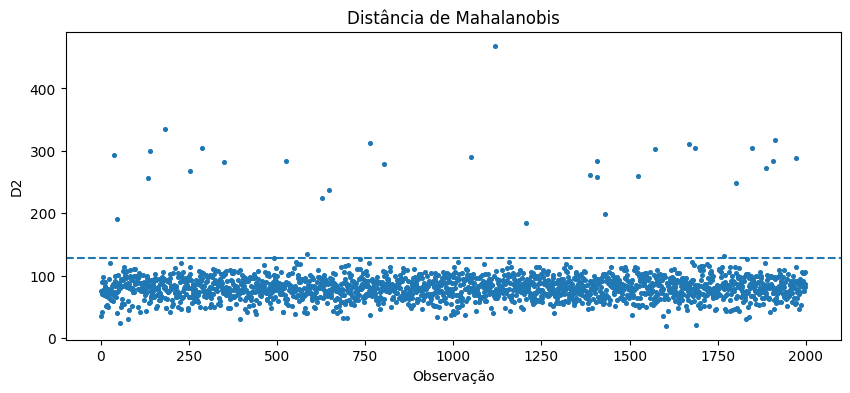

N de análise: 1968


In [11]:
mahalanobis_table, outlier_mask = mahalanobis_outliers(df[ITEM_CODES], alpha=MAHALANOBIS_ALPHA)
print('N bruto:', len(df))
print('Outliers:', int(outlier_mask.sum()))
print('Percentual:', f'{100*outlier_mask.mean():.2f}%')

display(mahalanobis_table.sort_values('mahalanobis_d2', ascending=False).head(20))

plt.figure(figsize=(10,4))
plt.scatter(np.arange(len(mahalanobis_table)), mahalanobis_table['mahalanobis_d2'], s=7)
plt.axhline(float(mahalanobis_table['cutoff'].iloc[0]), linestyle='--')
plt.title('Distância de Mahalanobis')
plt.xlabel('Observação')
plt.ylabel('D2')
plt.show()

analysis_df = df.copy() if KEEP_OUTLIERS else df.loc[~outlier_mask].reset_index(drop=True)
print('N de análise:', len(analysis_df))

# 10. Confiabilidade, KMO e Bartlett por construto

Além do Alfa, mostramos correlação item-total corrigida e Alfa caso cada item seja removido.

In [12]:
psych_rows = []
psych_details = {}

for construct, items in MEASUREMENT_BLOCKS.items():
    valid = [i for i in items if i in analysis_df.columns]
    if construct == 'DES' or len(valid) < 2:
        continue

    sub = analysis_df[valid]
    kt, ki = kmo(sub)
    bart = bartlett_sphericity(sub)
    alpha = cronbach_alpha(sub)

    psych_rows.append({
        'construct': construct,
        'n_items': len(valid),
        'alpha': alpha,
        'KMO': kt,
        'Bartlett_chi2': bart['chi2'],
        'Bartlett_df': bart['df'],
        'Bartlett_p': bart['p'],
        'alpha_ok': alpha >= ALPHA_THRESHOLD,
    })

    psych_details[construct] = pd.concat([
        corrected_item_total(sub),
        alpha_if_deleted(sub),
        ki,
    ], axis=1)

psych_summary = pd.DataFrame(psych_rows).set_index('construct').sort_index()
display(psych_summary)

for construct in ['ATEAD','SAT','COMP','FLEX','IES']:
    if construct in psych_details:
        print(f'\n{construct}')
        display(psych_details[construct])

,n_items,alpha,KMO,Bartlett_chi2,Bartlett_df,Bartlett_p,alpha_ok
construct,,,,,,,
ACFoco,3,0.9408,0.7630,"5,392.6378",3,0.0000,True
ACPlay,3,0.8405,0.7279,"2,373.7683",3,0.0000,True
AT,4,0.9467,0.8699,"7,680.2983",6,0.0000,True
ATEAD,8,0.9484,0.9630,"14,869.2425",28,0.0000,True
COMP,6,0.8473,0.8878,"4,522.0249",15,0.0000,True
FLEX,8,0.9478,0.9624,"13,872.0460",28,0.0000,True
FSI,6,0.9210,0.9286,"7,808.0816",15,0.0000,True
FUP,6,0.9601,0.9435,"13,155.4054",15,0.0000,True
IES,5,0.8522,0.8463,"5,346.7126",10,0.0000,True



ATEAD


,correlacao_item_total_corrigida,alpha_se_item_removido,KMO
ATEAD1,0.8588,0.9382,0.9603
ATEAD2,0.8515,0.9388,0.9625
ATEAD3,0.8590,0.9383,0.9608
ATEAD4,0.8592,0.9383,0.9589
ATEAD5,0.8430,0.9393,0.9656
ATEAD6,0.5190,0.9603,0.9860
ATEAD7,0.8634,0.9381,0.9602
ATEAD8,0.8484,0.9390,0.9638



SAT


,correlacao_item_total_corrigida,alpha_se_item_removido,KMO
SAT1,0.7200,0.6322,0.6023
SAT2,0.7152,0.6371,0.6036
SAT3,0.4947,0.8676,0.8553


...

,correlacao_item_total_corrigida,alpha_se_item_removido,KMO
COMP1,0.5040,0.8452,0.9321
COMP2,0.6784,0.8124,0.8819
COMP3,0.7005,0.8080,0.8797
COMP4,0.7008,0.8084,0.8801
COMP5,0.4865,0.8492,0.9310
COMP6,0.7159,0.8050,0.8656



FLEX


,correlacao_item_total_corrigida,alpha_se_item_removido,KMO
FLEX1,0.8130,0.9404,0.9678
FLEX2,0.8067,0.9409,0.9683
FLEX3,0.8451,0.9383,0.9600
FLEX4,0.5962,0.9540,0.9835
FLEX5,0.8556,0.9376,0.9564
FLEX6,0.8443,0.9383,0.9593
FLEX7,0.8501,0.9380,0.9588
FLEX8,0.8574,0.9375,0.9566



IES


,correlacao_item_total_corrigida,alpha_se_item_removido,KMO
IES1,0.8075,0.7828,0.8178
IES2,0.7705,0.7929,0.8473
IES3,0.8169,0.7795,0.8054
IES4,0.4572,0.8734,0.9448
IES5,0.4992,0.8632,0.9442


# 11. PCA global, análise paralela e EFA Varimax

A PCA global ajuda a visualizar dimensionalidade. Em seguida, a análise paralela informa quantas dimensões apresentam autovalores superiores aos esperados por acaso.

,eigenvalue,variance_ratio,cumulative
PC1,20.1788,0.2430,0.2430
PC2,6.5967,0.0794,0.3224
PC3,5.9960,0.0722,0.3946
PC4,5.3030,0.0639,0.4585
PC5,4.4413,0.0535,0.5120
PC6,3.7490,0.0451,0.5571
PC7,3.1403,0.0378,0.5949
PC8,2.7184,0.0327,0.6277
PC9,2.4340,0.0293,0.6570
PC10,2.2624,0.0272,0.6842


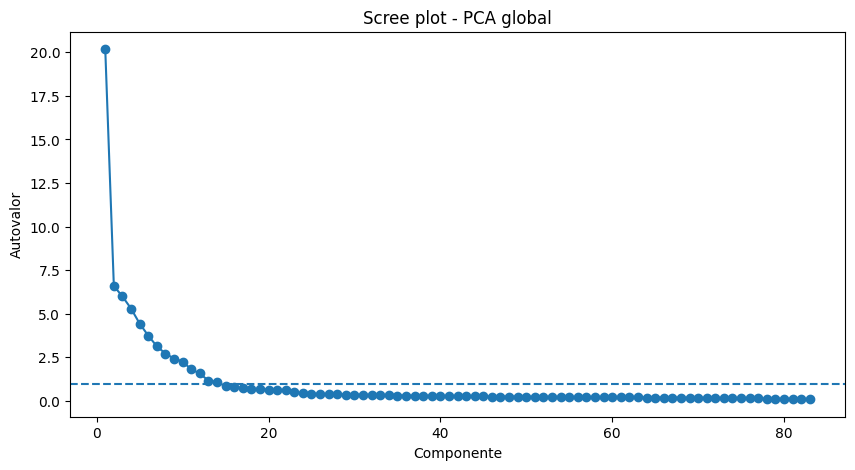

Dimensões sugeridas pela análise paralela: 12


,component,observed_eigenvalue,random_p95,retain
0,1,20.1686,1.4550,True
1,2,6.5933,1.4209,True
2,3,5.9930,1.3978,True
3,4,5.3003,1.3782,True
4,5,4.4391,1.3610,True
5,6,3.7471,1.3451,True
6,7,3.1387,1.3294,True
7,8,2.7170,1.3160,True
8,9,2.4328,1.3008,True
9,10,2.2613,1.2879,True


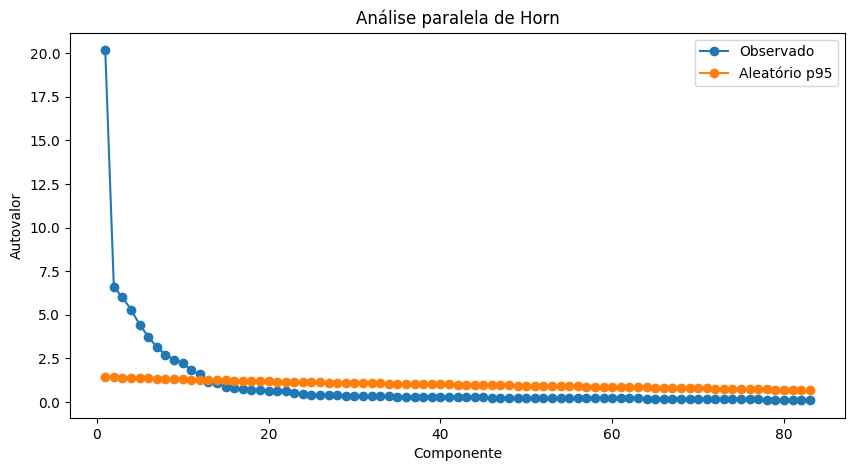

EFA - fatores: 12


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12
ATEAD1,-0.1333,0.0574,0.8659,-0.0435,0.0322,-0.0462,-0.0148,-0.0392,-0.0058,-0.0427,0.0402,0.0527
ATEAD2,-0.1030,0.0670,0.8660,-0.0469,0.0290,-0.0255,-0.0208,-0.0430,0.0059,-0.0295,0.0105,0.0531
ATEAD3,-0.0975,0.0495,0.8664,-0.0608,0.0377,-0.0237,-0.0278,-0.0504,-0.0115,-0.0745,0.0239,0.0671
ATEAD4,-0.0902,0.0660,0.8717,-0.0330,0.0299,-0.0505,-0.0125,-0.0228,-0.0030,-0.0763,0.0017,0.0628
ATEAD5,-0.1082,0.0617,0.8456,-0.0682,0.0356,-0.0411,-0.0308,-0.0197,0.0030,-0.0718,0.0274,0.0621
ATEAD6,-0.1011,0.0243,0.5123,-0.0526,-0.0032,-0.0324,-0.0703,0.0072,-0.0219,-0.0405,-0.0203,0.0398
ATEAD7,-0.1096,0.0509,0.8703,-0.0380,0.0428,-0.0185,-0.0244,-0.0463,-0.0067,-0.0492,0.0118,0.0739
ATEAD8,-0.1184,0.0582,0.8555,-0.0503,0.0358,-0.0239,-0.0270,-0.0430,-0.0219,-0.0331,0.0290,0.0731
SAT1,-0.1547,0.0533,0.7244,-0.0871,0.0312,-0.0279,-0.0117,-0.0331,-0.0307,-0.1809,0.0603,0.1047
SAT2,-0.1541,0.0668,0.7164,-0.0791,0.0474,-0.0131,0.0033,-0.0381,-0.0365,-0.1659,0.0562,0.0726


In [13]:
pca_global = run_pca(analysis_df[ITEM_CODES])
display(pca_global['explained'].head(30))

plt.figure(figsize=(10,5))
plt.plot(np.arange(1, len(pca_global['explained'])+1), pca_global['explained']['eigenvalue'], marker='o')
plt.axhline(1.0, linestyle='--')
plt.title('Scree plot - PCA global')
plt.xlabel('Componente')
plt.ylabel('Autovalor')
plt.show()

parallel = parallel_analysis(analysis_df[ITEM_CODES], iterations=PARALLEL_ITERATIONS, percentile=95, seed=RANDOM_SEED)
n_parallel = int(parallel['retain'].sum())
print('Dimensões sugeridas pela análise paralela:', n_parallel)
display(parallel.head(30))

plt.figure(figsize=(10,5))
plt.plot(parallel['component'], parallel['observed_eigenvalue'], marker='o', label='Observado')
plt.plot(parallel['component'], parallel['random_p95'], marker='o', label='Aleatório p95')
plt.title('Análise paralela de Horn')
plt.xlabel('Componente')
plt.ylabel('Autovalor')
plt.legend()
plt.show()

n_factors = int(max(1, min(n_parallel, 20)))
efa_loadings = exploratory_factor_analysis(analysis_df[ITEM_CODES], n_factors=n_factors, rotation='varimax', seed=RANDOM_SEED)
print('EFA - fatores:', n_factors)
display(efa_loadings.head(40))

# 12. PCA por construto e teste de Harman

A PCA por construto é um diagnóstico de unidimensionalidade local.

O fator único de Harman é apenas uma checagem histórica de common method bias. Um primeiro fator muito dominante merece atenção, mas o teste não é suficiente para provar ou excluir viés de método comum.

In [14]:
pc_rows=[]
pc_load_rows=[]
for construct, items in MEASUREMENT_BLOCKS.items():
    valid=[i for i in items if i in analysis_df.columns]
    if construct == 'DES' or len(valid) < 2:
        continue
    cp=run_pca(analysis_df[valid])
    first=cp['explained'].iloc[0]
    pc_rows.append({
        'construct':construct,
        'n_items':len(valid),
        'pc1_eigenvalue':first['eigenvalue'],
        'pc1_variance_ratio':first['variance_ratio'],
        'n_eigen_gt_1':int((cp['explained']['eigenvalue'] > 1).sum()),
    })
    for item,val in cp['loadings'].iloc[:,0].items():
        pc_load_rows.append({'construct':construct,'item':item,'PC1_loading':val})

pca_by_construct = pd.DataFrame(pc_rows).set_index('construct')
pca_by_construct_loadings = pd.DataFrame(pc_load_rows)
display(pca_by_construct)

harman = harman_single_factor(analysis_df[ITEM_CODES])
print('Harman:', harman)

,n_items,pc1_eigenvalue,pc1_variance_ratio,n_eigen_gt_1
construct,,,,
ACFoco,3,2.6845,0.8944,1
ACPlay,3,2.2759,0.7582,1
AT,4,3.4514,0.8624,1
ATEAD,8,5.9650,0.7452,1
COMP,6,3.4439,0.5737,1
FLEX,8,5.8911,0.7360,1
FSI,6,4.3050,0.7171,1
FUP,6,5.0074,0.8342,1
IES,5,3.2151,0.6427,1


Harman: {'first_eigenvalue': 20.168570703423036, 'first_factor_variance_pct': 24.29948277520847}


# 13. Modelo estrutural a partir da aba Hipoteses_Modelo

Os caminhos são lidos do XLS. Isso inclui a relação direta `UP -> IUE` presente nos resultados do SmartPLS, mesmo que não tenha sido numerada como uma das hipóteses principais no apêndice.

In [15]:
hcols = {str(c).strip().lower(): c for c in hypotheses_2014.columns}

def find_col(fragment):
    for low, original in hcols.items():
        if fragment in low:
            return original
    return None

source_col = find_col('origem')
target_col = find_col('destino')
hyp_col = find_col('hip')
beta_col = find_col('beta')
p2014_col = find_col('p 2014') or find_col('p_2014')
supported_col = find_col('suportada')

STRUCTURAL_PATHS = list(
    hypotheses_2014[[source_col,target_col]].astype(str).itertuples(index=False,name=None)
)

print('Caminhos:', len(STRUCTURAL_PATHS))
for p in STRUCTURAL_PATHS:
    print(p)

Caminhos: 28
('UP', 'AT')
('FUP', 'AT')
('AT', 'IUE')
('FUP', 'UP')
('IUE', 'DES')
('IUE', 'SAT')
('DES', 'SAT')
('SAT', 'ATEAD')
('FSI', 'UP')
('FSI', 'FUP')
('ISI', 'UP')
('ISI', 'FUP')
('QI', 'UP')
('INS', 'UP')
('INS', 'FUP')
('FLEX', 'FUP')
('IES', 'FUP')
('ACFoco', 'UP')
('ACFoco', 'FUP')
('ACPlay', 'UP')
('ACPlay', 'FUP')
('ORG', 'UP')
('ORG', 'FUP')
('ORG', 'DES')
('COMP', 'IUE')
('COMPxUP', 'IUE')
('COMP', 'DES')
('UP', 'IUE')


# 14. Primeiro estágio PLS: modelo de mensuração com todos os itens

A carga externa é a correlação entre indicador e escore do construto.

A dissertação eliminou indicadores com carga abaixo de 0,70 e itens problemáticos em cargas cruzadas. O código abaixo aplica a mesma lógica de forma transparente.

In [16]:
# Garante dados numéricos completos para a estimação.
for col in ITEM_CODES + ['DES']:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')
    analysis_df[col] = analysis_df[col].fillna(analysis_df[col].median())

blocks = {k:list(v) for k,v in MEASUREMENT_BLOCKS.items()}

pls_initial = PLSPathModel(blocks, STRUCTURAL_PATHS, interaction=('COMP','UP','COMPxUP'))
initial = pls_initial.fit(analysis_df)

display(initial.measurement.sort_index())
display(initial.outer_loadings.sort_values(['construct','loading']))

,n_indicators,cronbach_alpha,composite_reliability,AVE,sqrt_AVE,min_loading,max_loading
construct,,,,,,,
ACFoco,3,0.9408,0.9621,0.8943,0.9457,0.9328,0.9575
ACPlay,3,0.8405,0.9039,0.7581,0.8707,0.8655,0.8803
AT,4,0.9467,0.9616,0.8624,0.9287,0.9116,0.9417
ATEAD,8,0.9484,0.9584,0.7452,0.8632,0.5820,0.9021
COMP,6,0.8473,0.8880,0.5732,0.7571,0.5999,0.8345
DES,1,NaN,NaN,NaN,NaN,1.0000,1.0000
FLEX,8,0.9478,0.9567,0.7358,0.8578,0.6583,0.8982
FSI,6,0.9210,0.9383,0.7171,0.8468,0.8168,0.8678
FUP,6,0.9601,0.9679,0.8341,0.9133,0.8713,0.9410


,construct,item,loading
0,ACFoco,AC1,0.9328
2,ACFoco,AC3,0.9467
1,ACFoco,AC2,0.9575
4,ACPlay,AC5,0.8655
3,ACPlay,AC4,0.8662
...,...,...,...
77,UP,UP1,0.8756
81,UP,UP5,0.8803
82,UP,UP6,0.8814
78,UP,UP2,0.8828


In [17]:
# Depuração do modelo de mensuração segundo carga >= 0,70 e cross-loading.
loads = initial.outer_loadings.copy()
loads['abs_loading'] = loads['loading'].abs()
remove_rows=[]
refined_blocks={}

for construct, items in blocks.items():
    if construct == 'DES':
        refined_blocks[construct]=items
        continue

    kept=[]
    for item in items:
        row=loads[(loads.construct==construct) & (loads.item==item)]
        if row.empty:
            continue

        target=float(row.iloc[0].abs_loading)
        if item in initial.cross_loadings.index:
            cross=initial.cross_loadings.loc[item].drop(labels=[construct], errors='ignore').abs().max()
        else:
            cross=np.nan

        keep=(target >= LOADING_THRESHOLD) and (not np.isfinite(cross) or target > cross)
        if keep:
            kept.append(item)
        else:
            remove_rows.append({
                'construct':construct,
                'item':item,
                'loading':target,
                'max_cross_loading':cross,
                'reason':'loading<0.70' if target < LOADING_THRESHOLD else 'cross_loading',
            })

    # Evita construto degenerado por regra automática.
    if len(kept) < 2 and len(items) >= 2:
        rank=loads[loads.construct==construct].sort_values('abs_loading', ascending=False).item.tolist()[:2]
        kept=rank

    refined_blocks[construct]=kept

removed_items = pd.DataFrame(remove_rows)
print('Itens removidos automaticamente:')
display(removed_items)

final_counts = pd.Series({c:len(v) for c,v in refined_blocks.items()}, name='n_final_python').to_frame()
display(final_counts)

Itens removidos automaticamente:


,construct,item,loading,max_cross_loading,reason
0,ATEAD,ATEAD6,0.5820,0.4017,loading<0.70
1,COMP,COMP1,0.6364,0.1813,loading<0.70
2,COMP,COMP5,0.5999,0.1700,loading<0.70
3,FLEX,FLEX4,0.6583,0.1392,loading<0.70
4,IES,IES4,0.5871,0.1710,loading<0.70
5,IES,IES5,0.6347,0.1697,loading<0.70
6,SAT,SAT3,0.6830,0.4289,loading<0.70


,n_final_python
ACFoco,3
ACPlay,3
AT,4
ATEAD,7
COMP,4
FLEX,7
FSI,6
FUP,6
IES,3
INS,9


# 15. Segundo estágio PLS: modelo final

Agora são recalculados:

- cargas;
- pesos;
- Alfa;
- CR;
- AVE;
- Fornell-Larcker;
- HTMT;
- cross-loadings;
- caminhos;
- R2;
- f2;
- VIF;
- Q2;
- efeitos totais.

In [18]:
pls = PLSPathModel(refined_blocks, STRUCTURAL_PATHS, interaction=('COMP','UP','COMPxUP'))
result = pls.fit(analysis_df)

measurement_final = result.measurement.copy()
measurement_final['ok_alpha'] = measurement_final['cronbach_alpha'].isna() | (measurement_final['cronbach_alpha'] >= ALPHA_THRESHOLD)
measurement_final['ok_CR'] = measurement_final['composite_reliability'].isna() | (measurement_final['composite_reliability'] >= CR_THRESHOLD)
measurement_final['ok_AVE'] = measurement_final['AVE'].isna() | (measurement_final['AVE'] >= AVE_THRESHOLD)
measurement_final['ok_loading'] = measurement_final['min_loading'].isna() | (measurement_final['min_loading'] >= LOADING_THRESHOLD)

display(measurement_final.sort_index())
print('Fornell-Larcker')
display(result.fornell_larcker)
print('HTMT')
display(result.htmt)
print('Cross-loadings')
display(result.cross_loadings)

,n_indicators,cronbach_alpha,composite_reliability,AVE,sqrt_AVE,min_loading,max_loading,ok_alpha,ok_CR,ok_AVE,ok_loading
construct,,,,,,,,,,,
ACFoco,3,0.9408,0.9621,0.8943,0.9457,0.9328,0.9575,True,True,True,True
ACPlay,3,0.8405,0.9039,0.7581,0.8707,0.8655,0.8803,True,True,True,True
AT,4,0.9467,0.9616,0.8624,0.9287,0.9116,0.9417,True,True,True,True
ATEAD,7,0.9603,0.9671,0.8078,0.8988,0.8874,0.9042,True,True,True,True
COMP,4,0.8572,0.9031,0.6998,0.8366,0.8125,0.8552,True,True,True,True
DES,1,NaN,NaN,NaN,NaN,1.0000,1.0000,True,True,True,True
FLEX,7,0.9540,0.9621,0.7840,0.8854,0.8574,0.9016,True,True,True,True
FSI,6,0.9210,0.9383,0.7171,0.8468,0.8168,0.8678,True,True,True,True
FUP,6,0.9601,0.9679,0.8341,0.9133,0.8713,0.9410,True,True,True,True


Fornell-Larcker


,ACFoco,ACPlay,AT,ATEAD,COMP,FLEX,FSI,FUP,IES,INS,ISI,IUE,ORG,QI,SAT,UP
ACFoco,0.9457,0.3108,0.3878,0.1686,0.1592,0.1792,0.1791,0.2117,0.2063,0.2058,0.1296,0.3269,0.1825,0.1291,0.1798,0.4793
ACPlay,0.3108,0.8707,0.4623,0.2100,0.1573,0.1860,0.1643,0.2451,0.2027,0.1923,0.1530,0.3697,0.1737,0.1584,0.2226,0.5138
AT,0.3878,0.4623,0.9287,0.3137,0.1265,0.2027,0.3895,0.4667,0.2263,0.3260,0.1976,0.6244,0.1539,0.4113,0.3434,0.8019
ATEAD,0.1686,0.2100,0.3137,0.8988,0.1327,0.1090,0.1627,0.1983,0.0740,0.1589,0.1021,0.4381,0.1746,0.1530,0.7747,0.3210
COMP,0.1592,0.1573,0.1265,0.1327,0.8366,0.1784,0.1685,0.1709,0.1306,0.1826,0.1499,0.2805,0.3053,0.1425,0.1683,0.1552
FLEX,0.1792,0.1860,0.2027,0.1090,0.1784,0.8854,0.1959,0.2405,0.1585,0.1836,0.1476,0.2153,0.2092,0.1801,0.1019,0.2437
FSI,0.1791,0.1643,0.3895,0.1627,0.1685,0.1959,0.8468,0.7332,0.1608,0.1483,0.2838,0.3298,0.1963,0.3092,0.1848,0.4011
FUP,0.2117,0.2451,0.4667,0.1983,0.1709,0.2405,0.7332,0.9133,0.1942,0.3084,0.2612,0.3589,0.1817,0.2634,0.2185,0.4729
IES,0.2063,0.2027,0.2263,0.0740,0.1306,0.1585,0.1608,0.1942,0.9257,0.3123,0.1416,0.2023,0.1657,0.1414,0.1053,0.2703
INS,0.2058,0.1923,0.3260,0.1589,0.1826,0.1836,0.1483,0.3084,0.3123,0.8961,0.1163,0.2757,0.1856,0.1505,0.1628,0.3884


HTMT


,ACFoco,ACPlay,AT,ATEAD,COMP,FLEX,FSI,FUP,IES,INS,ISI,IUE,ORG,QI,SAT,UP
ACFoco,1.0000,0.3491,0.4105,0.1773,0.1757,0.1885,0.1918,0.2227,0.2217,0.2150,0.1375,0.3501,0.1930,0.1371,0.1989,0.5085
ACPlay,0.3491,1.0000,0.5180,0.2341,0.1849,0.2065,0.1854,0.2721,0.2291,0.2130,0.1714,0.4193,0.1940,0.1783,0.2604,0.5766
AT,0.4105,0.5180,1.0000,0.3288,0.1392,0.2120,0.4158,0.4889,0.2426,0.3398,0.2093,0.6671,0.1621,0.4368,0.3786,0.8484
ATEAD,0.1773,0.2341,0.3288,1.0000,0.1448,0.1137,0.1727,0.2065,0.0789,0.1646,0.1071,0.4655,0.1827,0.1611,0.8485,0.3373
COMP,0.1757,0.1849,0.1392,0.1448,1.0000,0.1966,0.1882,0.1870,0.1465,0.2006,0.1662,0.3134,0.3378,0.1576,0.1934,0.1712
FLEX,0.1885,0.2065,0.2120,0.1137,0.1966,1.0000,0.2089,0.2501,0.1693,0.1908,0.1559,0.2285,0.2190,0.1903,0.1115,0.2556
FSI,0.1918,0.1854,0.4158,0.1727,0.1882,0.2089,1.0000,0.7786,0.1745,0.1571,0.3041,0.3569,0.2099,0.3325,0.2065,0.4292
FUP,0.2227,0.2721,0.4889,0.2065,0.1870,0.2501,0.7786,1.0000,0.2063,0.3192,0.2739,0.3810,0.1899,0.2777,0.2390,0.4966
IES,0.2217,0.2291,0.2426,0.0789,0.1465,0.1693,0.1745,0.2063,1.0000,0.3307,0.1520,0.2191,0.1773,0.1531,0.1176,0.2901
INS,0.2150,0.2130,0.3398,0.1646,0.2006,0.1908,0.1571,0.3192,0.3307,1.0000,0.1213,0.2909,0.1933,0.1579,0.1774,0.4058


Cross-loadings


,ACFoco,ACPlay,AT,ATEAD,COMP,FLEX,FSI,FUP,IES,INS,ISI,IUE,ORG,QI,SAT,UP,DES
AC1,0.9328,0.2913,0.3519,0.1519,0.1366,0.1608,0.1654,0.1963,0.1978,0.1901,0.1270,0.2920,0.1666,0.1021,0.1558,0.4343,0.0415
AC2,0.9575,0.2974,0.3790,0.1645,0.1548,0.1698,0.1722,0.2057,0.2038,0.2095,0.1262,0.3268,0.1799,0.1294,0.1808,0.4743,0.0466
AC3,0.9467,0.2931,0.3685,0.1615,0.1599,0.1777,0.1706,0.1984,0.1835,0.1837,0.1144,0.3076,0.1710,0.1338,0.1728,0.4501,0.0539
AC4,0.2510,0.8662,0.4005,0.1879,0.1328,0.1613,0.1192,0.2045,0.1681,0.1608,0.1113,0.3146,0.1443,0.1322,0.1884,0.4289,0.0651
AC5,0.2800,0.8655,0.4042,0.1869,0.1484,0.1620,0.1504,0.2056,0.1648,0.1697,0.1497,0.3303,0.1506,0.1388,0.1974,0.4504,0.0704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UP3,0.4203,0.4605,0.7238,0.2878,0.1591,0.2238,0.3666,0.4286,0.2368,0.3467,0.2195,0.5310,0.1578,0.4480,0.3046,0.9000,0.0621
UP4,0.4311,0.4499,0.7027,0.2828,0.1280,0.2085,0.3492,0.4139,0.2336,0.3250,0.2071,0.5190,0.1342,0.4047,0.3063,0.8735,0.0537
UP5,0.4209,0.4556,0.7107,0.2837,0.1248,0.1966,0.3354,0.3995,0.2232,0.3105,0.2026,0.5118,0.1440,0.4298,0.2961,0.8803,0.0447
UP6,0.4266,0.4405,0.7080,0.2998,0.1417,0.2135,0.3721,0.4320,0.2421,0.3603,0.1877,0.5319,0.1510,0.3984,0.3183,0.8814,0.0417


# 16. Modelo estrutural e relevância explicativa/preditiva

## R2

\[
R^2=1-SS_{res}/SS_{tot}
\]

## f2

\[
f^2=rac{R^2_{incluido}-R^2_{excluido}}{1-R^2_{incluido}}
\]

Referências usuais: 0,02 pequeno, 0,15 médio, 0,35 grande.

## Q2

Aqui usamos cross-validation. `Q2 > 0` indica capacidade preditiva superior ao uso da média como referência.

In [19]:
print('Caminhos')
display(result.paths.sort_values(['target','source']))
print('R2')
display(result.r2.sort_index().to_frame())
print('f2')
display(result.f2.sort_values(['target','f2'], ascending=[True,False]))
print('VIF estrutural')
display(result.inner_vif.sort_values(['target','VIF'], ascending=[True,False]))
print('Q2 preditivo')
display(result.q2_predict.sort_index().to_frame())
print('Efeitos totais')
display(result.total_effects.sort_values('total', key=lambda s:s.abs(), ascending=False).head(60))

Caminhos


,source,target,beta
1,FUP,AT,0.1127
0,UP,AT,0.7486
19,SAT,ATEAD,0.7747
16,COMP,DES,0.0930
14,IUE,DES,-0.0318
15,ORG,DES,0.3818
25,ACFoco,FUP,0.0180
26,ACPlay,FUP,0.0826
23,FLEX,FUP,0.0567
20,FSI,FUP,0.6742


R2


,R2
AT,0.6529
ATEAD,0.6001
DES,0.1708
FUP,0.5912
IUE,0.4976
SAT,0.2793
UP,0.5996


f2


...

,target,predictor,VIF
1,AT,FUP,1.2880
0,AT,UP,1.2880
19,ATEAD,SAT,1.0000
16,DES,COMP,1.1691
15,DES,ORG,1.1171
14,DES,IUE,1.0995
25,FUP,ACFoco,1.1809
26,FUP,ACPlay,1.1759
22,FUP,INS,1.1746
24,FUP,IES,1.1722


Q2 preditivo


,Q2_predict
AT,0.6517
ATEAD,0.5991
DES,0.1673
FUP,0.5871
IUE,0.4950
SAT,0.2775
UP,0.5934


Efeitos totais


,source,target,direct,indirect,total
79,SAT,ATEAD,0.7747,0.0000,0.7747
80,UP,AT,0.7486,0.0000,0.7486
31,FSI,FUP,0.6742,0.0000,0.6742
82,UP,IUE,0.2099,0.3265,0.5363
64,IUE,SAT,0.4771,-0.0063,0.4708
15,AT,IUE,0.4361,0.0000,0.4361
72,ORG,DES,0.3818,0.0013,0.3831
63,IUE,ATEAD,0.0000,0.3647,0.3647
12,ACPlay,UP,0.3029,0.0130,0.3160
77,QI,UP,0.3083,0.0000,0.3083


# 17. Bootstrap dos caminhos

O bootstrap é não paramétrico: sorteia casos com reposição, reestima o modelo e usa a distribuição empírica dos coeficientes.

A configuração padrão deste notebook é **1.000 amostras**, como no estudo original.

Em amostras de 2.000 respondentes, esta célula pode levar alguns minutos. Use `FAST_MODE=True` apenas para depuração do notebook.

In [20]:
boot = pls.bootstrap(analysis_df, n_boot=BOOTSTRAP_SAMPLES, seed=RANDOM_SEED)
boot['significativo_0_05'] = boot['p_two_sided'] < 0.05
boot['IC95_exclui_zero'] = (boot['ci_2_5'] > 0) | (boot['ci_97_5'] < 0)
display(boot)

,source,target,beta,boot_mean,boot_se,t,p_two_sided,ci_2_5,ci_97_5,significativo_0_05,IC95_exclui_zero
0,FUP,AT,0.1127,0.1132,0.0152,7.4049,0.0000,0.0833,0.1440,True,True
1,UP,AT,0.7486,0.7483,0.0118,63.6505,0.0000,0.7252,0.7709,True,True
2,SAT,ATEAD,0.7747,0.7743,0.0095,81.2997,0.0000,0.7544,0.7922,True,True
3,COMP,DES,0.0930,0.0939,0.0207,4.4852,0.0000,0.0520,0.1345,True,True
4,IUE,DES,-0.0318,-0.0319,0.0212,-1.5005,0.1335,-0.0749,0.0103,False,False
5,ORG,DES,0.3818,0.3810,0.0201,19.0177,0.0000,0.3425,0.4193,True,True
6,ACFoco,FUP,0.0180,0.0189,0.0162,1.1144,0.2651,-0.0138,0.0487,False,False
7,ACPlay,FUP,0.0826,0.0827,0.0154,5.3823,0.0000,0.0515,0.1115,True,True
8,FLEX,FUP,0.0567,0.0572,0.0162,3.4900,0.0005,0.0273,0.0901,True,True
9,FSI,FUP,0.6742,0.6730,0.0130,51.7693,0.0000,0.6468,0.6985,True,True


# 18. Comparação com os resultados de 2014

A comparação serve como benchmark metodológico. Não é esperado que os dados sintéticos reproduzam exatamente cada beta, pois são uma nova amostra simulada e o algoritmo Python não é o SmartPLS original.

In [21]:
paths_python = result.paths.rename(columns={'beta':'beta_python'})
comparison = hypotheses_2014.merge(
    paths_python,
    left_on=[source_col,target_col],
    right_on=['source','target'],
    how='left'
)
comparison = comparison.merge(
    boot[['source','target','p_two_sided','t','ci_2_5','ci_97_5','significativo_0_05']],
    on=['source','target'],
    how='left'
)
if beta_col:
    comparison['delta_beta_python_2014'] = comparison['beta_python'] - pd.to_numeric(comparison[beta_col], errors='coerce')
display(comparison)

# Benchmark de mensuração.
construct_b = next(c for c in benchmarks_2014.columns if 'construto' in str(c).lower())
benchmark_measurement = benchmarks_2014.merge(
    result.measurement.reset_index(),
    left_on=construct_b,
    right_on='construct',
    how='left',
    suffixes=('_2014','_python')
)
display(benchmark_measurement)

,Origem,Destino,Hipotese,Sinal_esperado,Beta_2014,p_2014,Suportada_2014,source,target,beta_python,p_two_sided,t,ci_2_5,ci_97_5,significativo_0_05,delta_beta_python_2014
0,UP,AT,H1,+,0.7980,0.0000,SIM,UP,AT,0.7486,0.0000,63.6505,0.7252,0.7709,True,-0.0494
1,FUP,AT,H2,+,0.1000,0.0390,SIM,FUP,AT,0.1127,0.0000,7.4049,0.0833,0.1440,True,0.0127
2,AT,IUE,H3,+,0.3620,0.0010,SIM,AT,IUE,0.4361,0.0000,16.6381,0.3822,0.4860,True,0.0741
3,FUP,UP,H4,+,0.1100,0.2040,NAO,FUP,UP,0.1579,0.0000,7.1056,0.1137,0.2035,True,0.0479
4,IUE,DES,H5,+,-0.0260,0.7180,NAO,IUE,DES,-0.0318,0.1335,-1.5005,-0.0749,0.0103,False,-0.0058
5,IUE,SAT,H6,+,0.5330,0.0000,SIM,IUE,SAT,0.4771,0.0000,26.6157,0.4404,0.5096,True,-0.0559
6,DES,SAT,H7,+,0.2110,0.0020,SIM,DES,SAT,0.1978,0.0000,10.5127,0.1630,0.2352,True,-0.0132
7,SAT,ATEAD,H8,+,0.8660,0.0000,SIM,SAT,ATEAD,0.7747,0.0000,81.2997,0.7544,0.7922,True,-0.0913
8,FSI,UP,H9a,+,0.0550,0.4610,NAO,FSI,UP,0.0677,0.0026,3.0111,0.0234,0.1117,True,0.0127
9,FSI,FUP,H9b,+,0.6130,0.0000,SIM,FSI,FUP,0.6742,0.0000,51.7693,0.6468,0.6985,True,0.0612


,Construto,AVE_2014,CR_2014,Alpha_2014,N_indicadores_final_2014,construct,n_indicators,cronbach_alpha,composite_reliability,AVE,sqrt_AVE,min_loading,max_loading
0,ACFoco,0.9000,0.9600,0.9400,3,ACFoco,3,0.9408,0.9621,0.8943,0.9457,0.9328,0.9575
1,ACPlay,0.7000,0.8700,0.7800,3,ACPlay,3,0.8405,0.9039,0.7581,0.8707,0.8655,0.8803
2,AT,0.8500,0.9600,0.9400,4,AT,4,0.9467,0.9616,0.8624,0.9287,0.9116,0.9417
3,ATEAD,0.8000,0.9600,0.9600,7,ATEAD,7,0.9603,0.9671,0.8078,0.8988,0.8874,0.9042
4,COMP,0.6300,0.8700,0.8100,4,COMP,4,0.8572,0.9031,0.6998,0.8366,0.8125,0.8552
5,FLEX,0.7600,0.9500,0.9300,7,FLEX,7,0.9540,0.9621,0.7840,0.8854,0.8574,0.9016
6,FSI,0.7400,0.9400,0.9300,6,FSI,6,0.9210,0.9383,0.7171,0.8468,0.8168,0.8678
7,FUP,0.8600,0.9700,0.9700,6,FUP,6,0.9601,0.9679,0.8341,0.9133,0.8713,0.9410
8,IES,0.8300,0.9300,0.9000,3,IES,3,0.9167,0.9473,0.8570,0.9257,0.9107,0.9332
9,INS,0.8300,0.9800,0.9800,9,INS,9,0.9693,0.9735,0.8030,0.8961,0.8719,0.9166


# 19. Gráficos do modelo

A figura seguinte usa largura proporcional à magnitude do beta. Caminhos contínuos são significativos no bootstrap a 5%; tracejados não são.

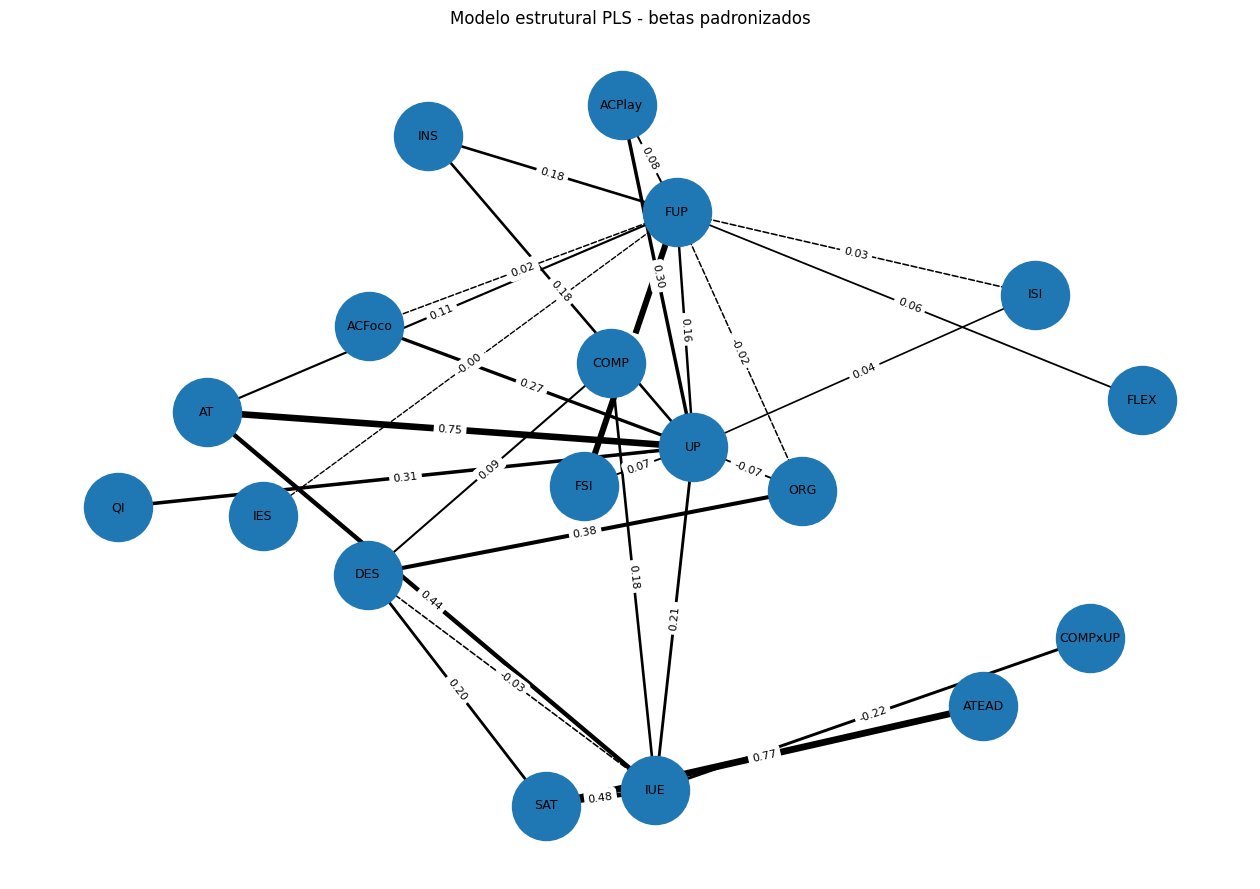

In [22]:
G=nx.DiGraph()
for c in result.scores.columns:
    G.add_node(c)
boot_idx=boot.set_index(['source','target'])
for _,r in result.paths.iterrows():
    key=(r['source'],r['target'])
    p=float(boot_idx.loc[key,'p_two_sided']) if key in boot_idx.index else np.nan
    G.add_edge(r['source'],r['target'],beta=float(r['beta']),p=p)

plt.figure(figsize=(16,11))
pos=nx.spring_layout(G, seed=RANDOM_SEED, k=1.3)
nx.draw_networkx_nodes(G,pos,node_size=2400)
nx.draw_networkx_labels(G,pos,font_size=9)

sig=[]; nonsig=[]; ws=[]; wn=[]
for u,v,d in G.edges(data=True):
    width=1+5*abs(d['beta'])
    if np.isfinite(d['p']) and d['p']<0.05:
        sig.append((u,v)); ws.append(width)
    else:
        nonsig.append((u,v)); wn.append(width)

nx.draw_networkx_edges(G,pos,edgelist=sig,width=ws,arrows=True)
nx.draw_networkx_edges(G,pos,edgelist=nonsig,width=wn,style='dashed',arrows=True)
nx.draw_networkx_edge_labels(G,pos,edge_labels={(u,v):f"{d['beta']:.2f}" for u,v,d in G.edges(data=True)},font_size=8)
plt.title('Modelo estrutural PLS - betas padronizados')
plt.axis('off')
plt.show()

# 20. Checklist de interpretação

## Antes do modelo estrutural

Verifique:

- faixa correta da escala;
- itens reversos corretamente codificados;
- outliers documentados;
- Alfa e CR;
- cargas externas;
- AVE;
- Fornell-Larcker;
- HTMT;
- cross-loadings.

## Depois

Interprete em conjunto:

- sinal e magnitude do beta;
- intervalo de confiança bootstrap;
- `p`;
- R2;
- f2;
- VIF;
- Q2;
- efeitos indiretos e totais.

### Significância não é tamanho de efeito

Com n=2.000, efeitos pequenos podem ser estatisticamente significativos. A conclusão substantiva deve combinar teoria e tamanho de efeito.

# 21. Exportação de todos os resultados

A execução gera CSVs, um XLSX consolidado, um JSON de resumo e um ZIP final para download.

In [23]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

result_tables = {
    '01_validacao_likert': likert_validation,
    '02_descritivos': descriptives.reset_index(),
    '03_frequencias': frequencies,
    '04_normalidade': normality.reset_index(),
    '05_mahalanobis': mahalanobis_table.reset_index(),
    '06_psicometria_resumo': psych_summary.reset_index(),
    '07_pca_variancia': pca_global['explained'].reset_index(),
    '08_pca_loadings': pca_global['loadings'].reset_index(names='item'),
    '09_parallel_analysis': parallel,
    '10_efa_varimax': efa_loadings.reset_index(names='item'),
    '10b_pca_construtos': pca_by_construct.reset_index(),
    '10c_pca_construtos_loadings': pca_by_construct_loadings,
    '11_pls_initial_measurement': initial.measurement.reset_index(),
    '12_itens_removidos': removed_items,
    '13_pls_final_measurement': result.measurement.reset_index(),
    '14_pls_outer_loadings': result.outer_loadings,
    '15_pls_cross_loadings': result.cross_loadings.reset_index(names='item'),
    '16_fornell_larcker': result.fornell_larcker.reset_index(names='construct'),
    '17_htmt': result.htmt.reset_index(names='construct'),
    '18_paths': result.paths,
    '19_r2': result.r2.reset_index().rename(columns={'index':'construct'}),
    '20_f2': result.f2,
    '21_inner_vif': result.inner_vif,
    '22_q2': result.q2_predict.reset_index().rename(columns={'index':'construct'}),
    '23_total_effects': result.total_effects,
    '24_bootstrap': boot,
    '25_comparacao_2014': comparison,
    '26_benchmark_measurement': benchmark_measurement,
}

for name,t in result_tables.items():
    t.to_csv(OUTPUT_DIR/f'{name}.csv',index=False,encoding='utf-8-sig')

excel_out=OUTPUT_DIR/'Resultados_Dissertacao_Zaroni_Python.xlsx'
with pd.ExcelWriter(excel_out,engine='openpyxl') as writer:
    for name,t in result_tables.items():
        t.to_excel(writer,sheet_name=name[:31],index=False)

summary={
    'n_raw':int(len(df_raw)),
    'n_outliers':int(outlier_mask.sum()),
    'n_analysis':int(len(analysis_df)),
    'mahalanobis_alpha':MAHALANOBIS_ALPHA,
    'bootstrap_samples':BOOTSTRAP_SAMPLES,
    'parallel_iterations':PARALLEL_ITERATIONS,
    'parallel_factors':int(n_parallel),
    'harman_first_factor_pct':float(harman['first_factor_variance_pct']),
    'r2':{str(k):float(v) for k,v in result.r2.items()},
    'q2':{str(k):float(v) for k,v in result.q2_predict.items()},
}
(OUTPUT_DIR/'SUMMARY.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2),encoding='utf-8')

zip_out=Path('/content/Zaroni_Resultados_Estatisticos.zip')
with zipfile.ZipFile(zip_out,'w',compression=zipfile.ZIP_DEFLATED) as z:
    for p in OUTPUT_DIR.rglob('*'):
        if p.is_file():
            z.write(p,arcname=p.relative_to(OUTPUT_DIR))

print('XLSX consolidado:',excel_out)
print('ZIP:',zip_out)
print(json.dumps(summary,ensure_ascii=False,indent=2))

try:
    from google.colab import files
    print("Para baixar: files.download('/content/Zaroni_Resultados_Estatisticos.zip')")
except Exception:
    pass

XLSX consolidado: /content/zaroni_resultados/Resultados_Dissertacao_Zaroni_Python.xlsx
ZIP: /content/Zaroni_Resultados_Estatisticos.zip
{
  "n_raw": 2000,
  "n_outliers": 32,
  "n_analysis": 1968,
  "mahalanobis_alpha": 0.001,
  "bootstrap_samples": 1000,
  "parallel_iterations": 300,
  "parallel_factors": 12,
  "harman_first_factor_pct": 24.29948277520847,
  "r2": {
    "AT": 0.6528930456773236,
    "IUE": 0.4976032102920105,
    "UP": 0.5995843359330373,
    "DES": 0.17083824014602078,
    "SAT": 0.279285466364792,
    "ATEAD": 0.6001123334121226,
    "FUP": 0.5912468422583712
  },
  "q2": {
    "AT": 0.6517176688455515,
    "IUE": 0.49500490735874036,
    "UP": 0.5934220628362463,
    "DES": 0.16731204281776857,
    "SAT": 0.2774701068854173,
    "ATEAD": 0.5990907246513194,
    "FUP": 0.5870727215298273
  }
}
Para baixar: files.download('/content/Zaroni_Resultados_Estatisticos.zip')


# 22. Limitações técnicas da reprodução

1. O XLS incluído é sintético e não substitui a base real de 2014.
2. O PLS é implementado em Python e não usa o motor proprietário do SmartPLS 2.0.M3.
3. A escala `DES` do XLS sintético usa 0 a 10 para permitir testes. A dissertação define o desempenho como coeficiente de rendimento obtido do LMS, sem impor no apêndice uma escala universal.
4. A exclusão automática de indicadores é útil para auditoria e teste. Em uma pesquisa real, conteúdo e teoria devem prevalecer sobre decisões puramente algorítmicas.
5. PCA e EFA são diagnósticos complementares. Elas não substituem a avaliação confirmatória do modelo de mensuração PLS.